# 1D CNN Hourly Rainfall Forecasting Using Sensor Data

This notebook trains a Convolutional Neural Network rainfall forecasting model. The model predicts the rainfall amount (in mm) directly from a sliding window of sensor readings (temperature, humidity, soil temperature, shortwave radiation, and evapotranspiration).

## 1. Imports

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import tensorflow as tf
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, confusion_matrix, ConfusionMatrixDisplay
from tensorflow.keras import Model
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.layers import Conv1D, MaxPooling1D, GlobalAveragePooling1D, Dense, Input

tf.keras.utils.set_random_seed(42)
np.random.seed(42)

BASE_DIR = Path.cwd()
PROJECT_DIR = BASE_DIR.parent
DATA_PATH = PROJECT_DIR / 'weather_irrigation_hourly' / 'historical_weather_data_hourly.csv'
KERAS_MODEL_PATH = BASE_DIR / 'cnn_rainfall_forecaster.keras'
TFLITE_MODEL_PATH = BASE_DIR / 'cnn_rainfall_forecaster.tflite'
CC_MODEL_PATH = BASE_DIR / 'cnn_rainfall_forecaster.cc'
H_MODEL_PATH = BASE_DIR / 'cnn_rainfall_forecaster.h'
METRICS_PATH = BASE_DIR / 'cnn_rainfall_metrics.json'
FEATURE_COLUMNS_PATH = BASE_DIR / 'cnn_feature_columns.json'
X_MEAN_PATH = BASE_DIR / 'cnn_X_mean.npy'
X_STD_PATH = BASE_DIR / 'cnn_X_std.npy'
Y_AMOUNT_MEAN_PATH = BASE_DIR / 'cnn_y_amount_mean.npy'
Y_AMOUNT_STD_PATH = BASE_DIR / 'cnn_y_amount_std.npy'
RAIN_THRESHOLD_MM = 0.1
C_ARRAY_NAME = 'cnn_rainfall_forecaster_tflite'
TIME_STEPS = 24

FEATURES = [
    'temperature_2m',
    'relative_humidity_2m',
    'soil_temperature_0_to_7cm',
    'shortwave_radiation',
    'et0_fao_evapotranspiration_mm',
]


I0000 00:00:1779202030.266296  726156 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE3 SSE4.1 SSE4.2 AVX AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


## 2. Load Data

In [2]:
if not DATA_PATH.exists():
    raise FileNotFoundError(
        'historical_weather_data_hourly.csv was not found.'
    )

df = pd.read_csv(DATA_PATH, parse_dates=['time'])
df = df.sort_values('time').reset_index(drop=True)
df['precipitation_mm'] = df['precipitation_mm'].clip(lower=0)
df = df.dropna(subset=FEATURES + ['precipitation_mm'])
print(df[['time', 'precipitation_mm'] + FEATURES].head())
print(f'Loaded {len(df):,} hourly rows from {df.time.min()} to {df.time.max()}')


                 time  precipitation_mm  temperature_2m  relative_humidity_2m  \
0 2015-01-01 00:00:00               0.0            15.0                    70   
1 2015-01-01 01:00:00               0.0            14.0                    72   
2 2015-01-01 02:00:00               0.0            13.5                    73   
3 2015-01-01 03:00:00               0.0            13.2                    72   
4 2015-01-01 04:00:00               0.0            12.6                    74   

   soil_temperature_0_to_7cm  shortwave_radiation  \
0                       14.3                  0.0   
1                       13.8                  0.0   
2                       13.4                  0.0   
3                       12.9                  0.0   
4                       12.5                  0.0   

   et0_fao_evapotranspiration_mm  
0                            0.0  
1                            0.0  
2                            0.0  
3                            0.0  
4                  

## 3. Data Exploration

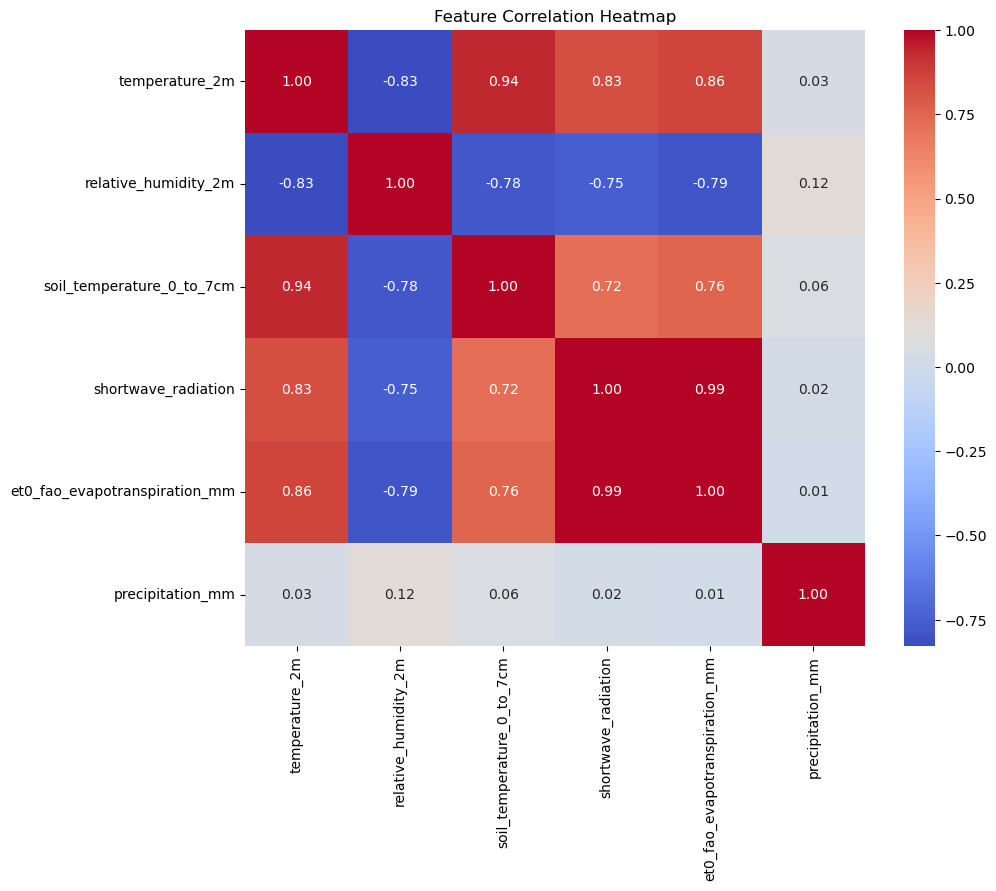

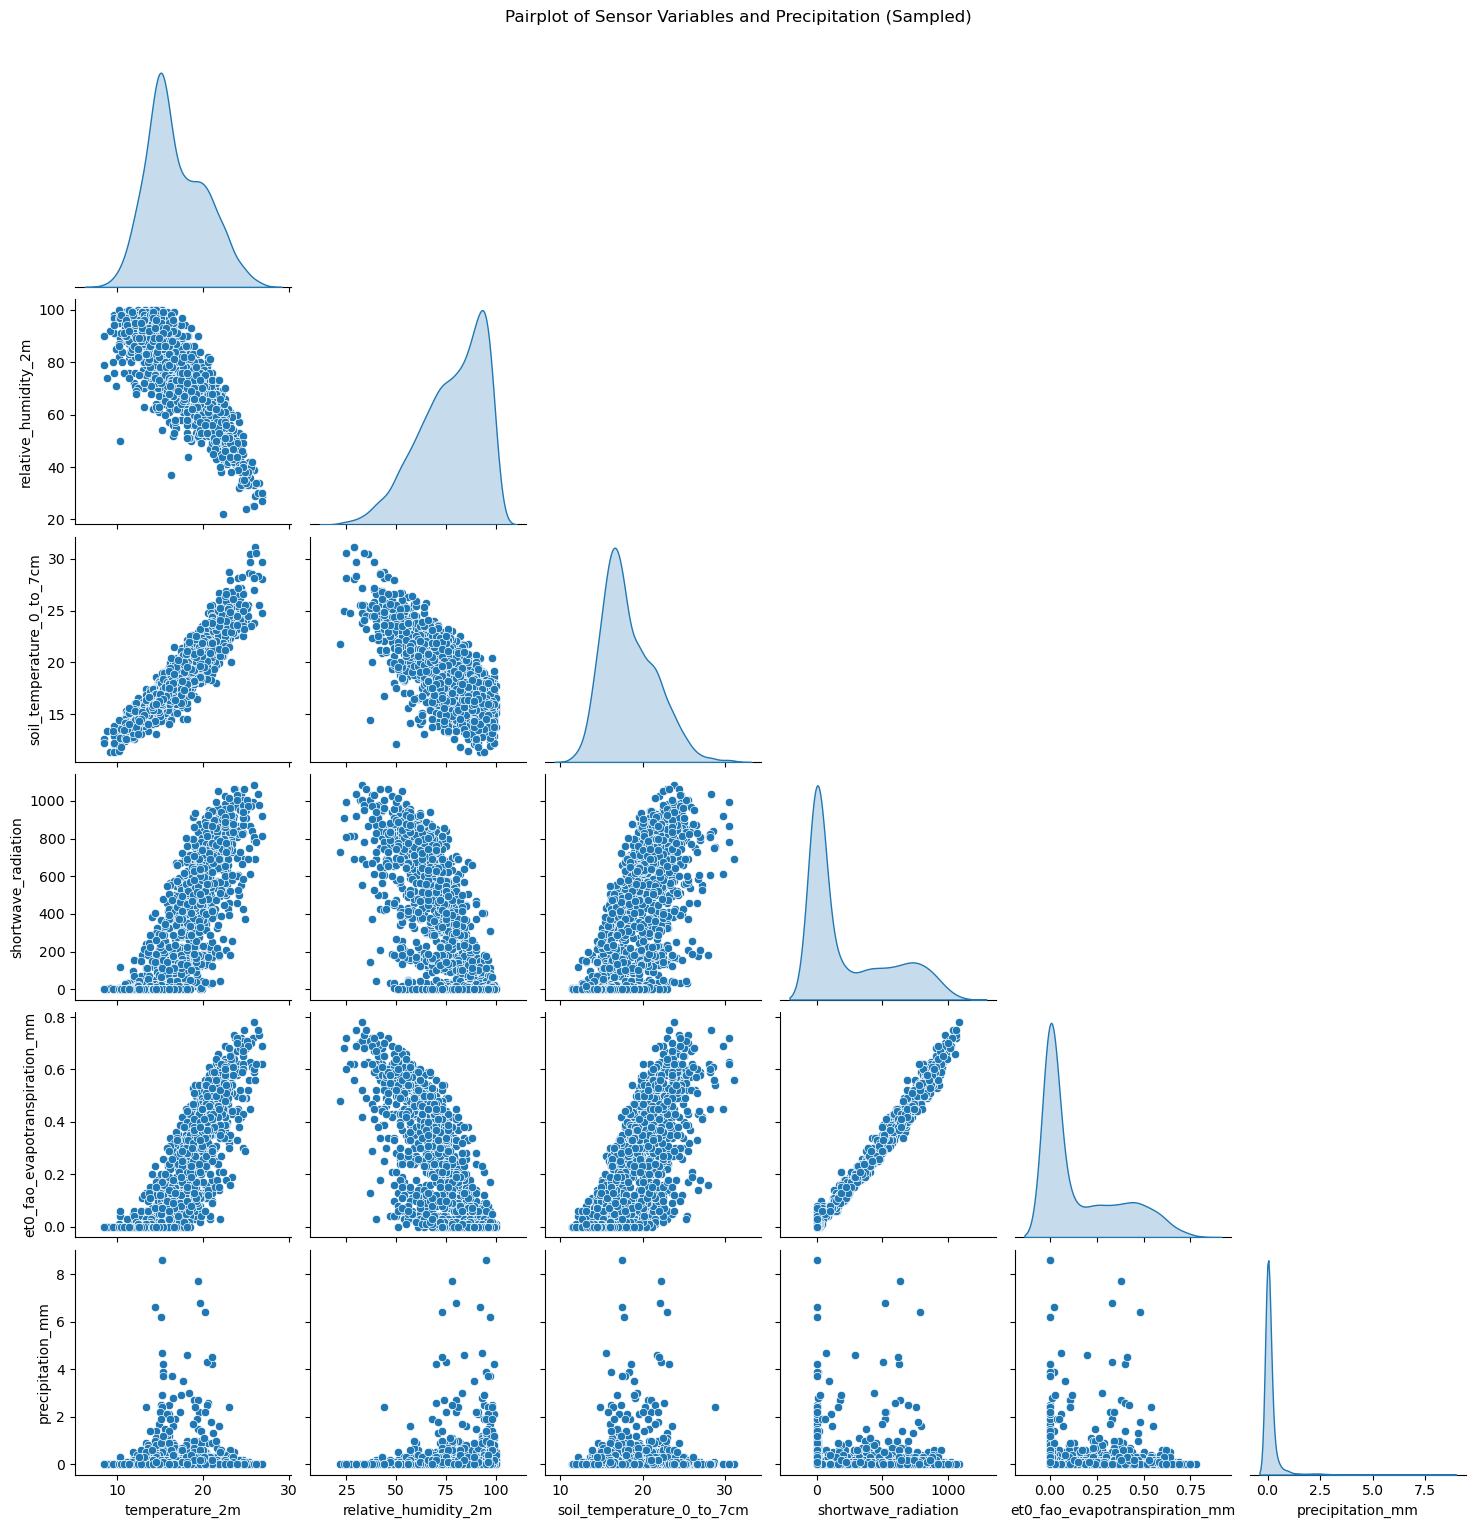

In [3]:
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(df[FEATURES + ['precipitation_mm']].corr(), annot=True, cmap='coolwarm', ax=ax, fmt='.2f')
ax.set_title('Feature Correlation Heatmap')
plt.show()

sns.pairplot(df[FEATURES + ['precipitation_mm']].sample(n=min(2000, len(df))), corner=True, diag_kind='kde')
plt.suptitle('Pairplot of Sensor Variables and Precipitation (Sampled)', y=1.02)
plt.show()


## 4. Time-Based Split And Sequence Generation

In [4]:
split_idx = int(len(df) * 0.8)
train_df = df.iloc[:split_idx].copy()
test_df = df.iloc[split_idx:].copy()

X_train_base = train_df[FEATURES].to_numpy(dtype=np.float32)
X_test_base = test_df[FEATURES].to_numpy(dtype=np.float32)
y_train_amount_base = train_df['precipitation_mm'].to_numpy(dtype=np.float32)
y_test_amount_base = test_df['precipitation_mm'].to_numpy(dtype=np.float32)

X_mean = X_train_base.mean(axis=0)
X_std = X_train_base.std(axis=0)
X_std[X_std == 0] = 1e-6
X_train_scaled_base = (X_train_base - X_mean) / X_std
X_test_scaled_base = (X_test_base - X_mean) / X_std

def create_sequences(features, y_amount, time_steps):
    X, y_a = [], []
    for i in range(len(features) - time_steps + 1):
        X.append(features[i : i + time_steps])
        y_a.append(y_amount[i + time_steps - 1])
    return np.array(X), np.array(y_a)

X_train_scaled, y_train_amount = create_sequences(X_train_scaled_base, y_train_amount_base, TIME_STEPS)
X_test_scaled, y_test_amount = create_sequences(X_test_scaled_base, y_test_amount_base, TIME_STEPS)

y_train_amount_log = np.log1p(y_train_amount)
y_amount_mean = float(y_train_amount_log.mean())
y_amount_std = float(y_train_amount_log.std())
if y_amount_std == 0:
    y_amount_std = 1e-6
y_train_amount_scaled = ((y_train_amount_log - y_amount_mean) / y_amount_std).astype(np.float32)

np.save(X_MEAN_PATH, X_mean)
np.save(X_STD_PATH, X_std)
np.save(Y_AMOUNT_MEAN_PATH, np.array([y_amount_mean], dtype=np.float32))
np.save(Y_AMOUNT_STD_PATH, np.array([y_amount_std], dtype=np.float32))
FEATURE_COLUMNS_PATH.write_text(json.dumps(FEATURES, indent=2))
print(f'Train sequences: {len(X_train_scaled):,}, test sequences: {len(X_test_scaled):,}')
print(f'Sequence shape: {X_train_scaled.shape}')


Train sequences: 77,122, test sequences: 19,264
Sequence shape: (77122, 24, 5)


## 5. TensorFlow CNN Model

In [5]:
inputs = Input(shape=(TIME_STEPS, len(FEATURES)), name='sensor_sequence')
x = Conv1D(filters=32, kernel_size=3, activation='relu')(inputs)
x = MaxPooling1D(pool_size=2)(x)
x = Conv1D(filters=16, kernel_size=3, activation='relu')(x)
x = GlobalAveragePooling1D()(x)
x = Dense(16, activation='relu')(x)
amount_output = Dense(1, name='amount_output')(x)

model = Model(inputs=inputs, outputs=amount_output)
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='mse',
)
model.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sensor_sequence (InputLayer)    │ (None, 24, 5)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 22, 32)         │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 11, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 9, 16)          │         1,552 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 16)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ amount_output (Dense)           │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,353 (9.19 KB)

 Trainable params: 2,353 (9.19 KB)

 Non-trainable params: 0 (0.00 B)

## 6. Train

In [6]:
callbacks = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
]

history = model.fit(
    X_train_scaled,
    y_train_amount_scaled,
    validation_split=0.15,
    epochs=40,
    batch_size=256,
    verbose=1,
    callbacks=callbacks,
)

print(f"Training stopped after {len(history.history['loss'])} epochs.")
print(f"Best val_loss: {min(history.history['val_loss']):.4f}")


Epoch 1/40


W0000 00:00:1779202039.179494  726156 cpu_allocator_impl.cc:82] Allocation of 31465440 exceeds 10% of free system memory.


  1/257 ━━━━━━━━━━━━━━━━━━━━ 13:15 3s/step - loss: 1.5500

  6/257 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 1.2067 

 12/257 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 1.1471 

...

240/257 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.7805

247/257 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.7794

253/257 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.7785

257/257 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 0.7398 - val_loss: 0.4034


Training stopped after 40 epochs.
Best val_loss: 0.4034


## 7. Evaluate

In [7]:
amount_pred_scaled = model.predict(X_test_scaled, verbose=0)
amount_pred_scaled = amount_pred_scaled.reshape(-1)
amount_pred = np.expm1((amount_pred_scaled * y_amount_std) + y_amount_mean).clip(min=0)
rainy_mask = y_test_amount >= RAIN_THRESHOLD_MM

def amount_metrics(y_true, y_pred):
    rainy_true = y_true[rainy_mask]
    rainy_pred = y_pred[rainy_mask]
    return {
        'mae_mm': float(mean_absolute_error(y_true, y_pred)),
        'rmse_mm': float(mean_squared_error(y_true, y_pred)**0.5),
        'r2': float(r2_score(y_true, y_pred)),
        'rainy_hours_count': int(rainy_mask.sum()),
        'rainy_mae_mm': float(mean_absolute_error(rainy_true, rainy_pred)) if len(rainy_true) > 0 else 0.0,
        'rainy_rmse_mm': float(mean_squared_error(rainy_true, rainy_pred)**0.5) if len(rainy_true) > 0 else 0.0,
    }

metrics = {
    'train_rows': int(len(X_train_scaled)),
    'test_rows': int(len(X_test_scaled)),
    'feature_columns': FEATURES,
    'time_steps': TIME_STEPS,
    'amount_models': {
        'cnn_1d_sequence': amount_metrics(y_test_amount, amount_pred),
    },
    'selected_amount_model': 'cnn_1d_sequence',
}
print(json.dumps(metrics, indent=2))


{
  "train_rows": 77122,
  "test_rows": 19264,
  "feature_columns": [
    "temperature_2m",
    "relative_humidity_2m",
    "soil_temperature_0_to_7cm",
    "shortwave_radiation",
    "et0_fao_evapotranspiration_mm"
  ],
  "time_steps": 24,
  "amount_models": {
    "cnn_1d_sequence": {
      "mae_mm": 0.18078948557376862,
      "rmse_mm": 0.500839452589781,
      "r2": 0.2349596619606018,
      "rainy_hours_count": 5826,
      "rainy_mae_mm": 0.357997864484787,
      "rainy_rmse_mm": 0.8651351699617161
    }
  },
  "selected_amount_model": "cnn_1d_sequence"
}


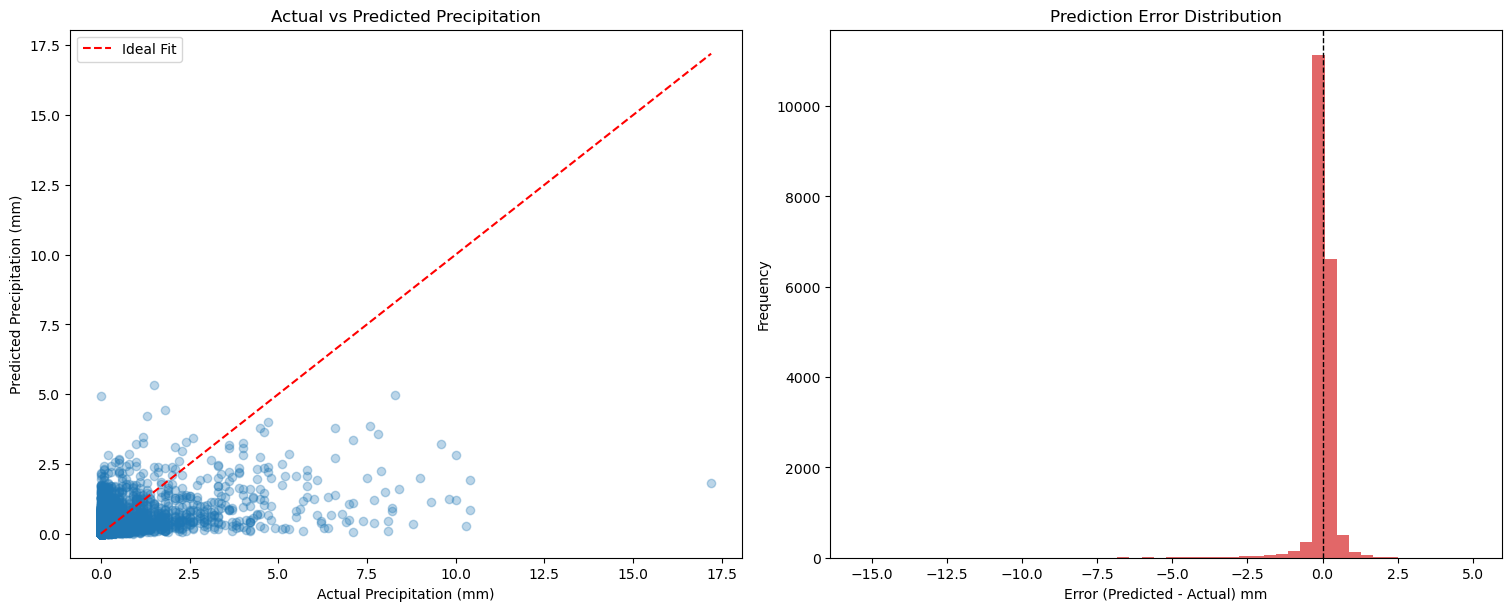

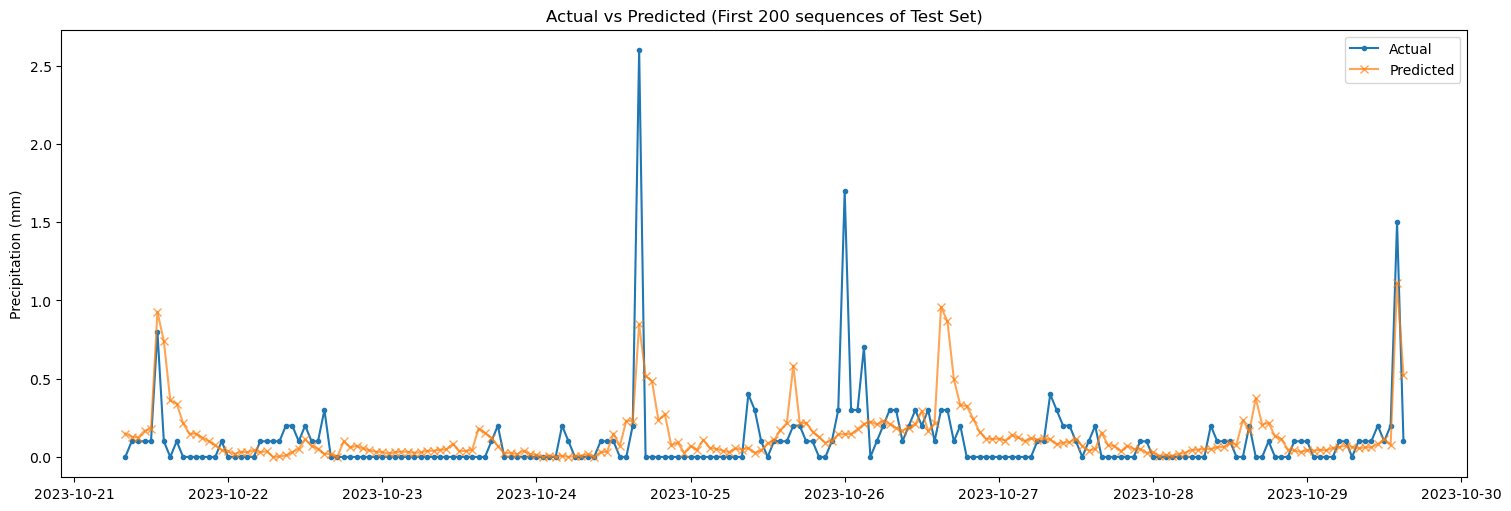

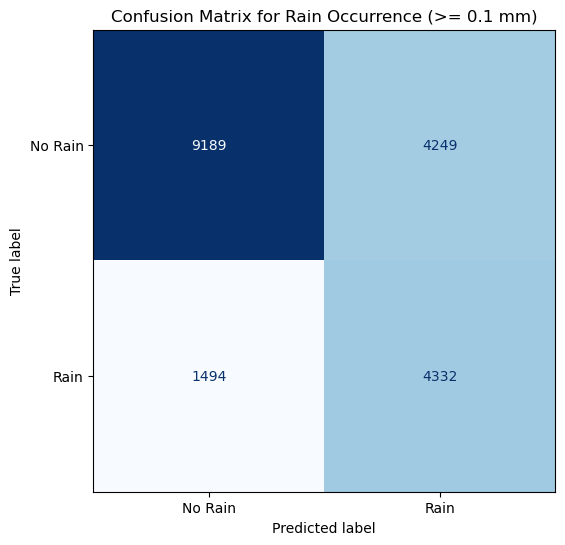

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6), constrained_layout=True)

axes[0].scatter(y_test_amount, amount_pred, alpha=0.3, color='tab:blue')
axes[0].plot([0, y_test_amount.max()], [0, y_test_amount.max()], 'r--', label='Ideal Fit')
axes[0].set_title('Actual vs Predicted Precipitation')
axes[0].set_xlabel('Actual Precipitation (mm)')
axes[0].set_ylabel('Predicted Precipitation (mm)')
axes[0].legend()

error = amount_pred - y_test_amount
axes[1].hist(error, bins=50, color='tab:red', alpha=0.7)
axes[1].axvline(0, color='black', linestyle='dashed', linewidth=1)
axes[1].set_title('Prediction Error Distribution')
axes[1].set_xlabel('Error (Predicted - Actual) mm')
axes[1].set_ylabel('Frequency')
plt.show()

fig, ax = plt.subplots(figsize=(15, 5), constrained_layout=True)
plot_slice = slice(0, 200)
time_slice = test_df['time'].iloc[TIME_STEPS-1:TIME_STEPS-1+200]
ax.plot(time_slice, y_test_amount[plot_slice], label='Actual', marker='.', color='tab:blue')
ax.plot(time_slice, amount_pred[plot_slice], label='Predicted', marker='x', color='tab:orange', alpha=0.7)
ax.set_title('Actual vs Predicted (First 200 sequences of Test Set)')
ax.set_ylabel('Precipitation (mm)')
ax.legend()
plt.show()

cm = confusion_matrix(y_test_amount >= RAIN_THRESHOLD_MM, amount_pred >= RAIN_THRESHOLD_MM)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Rain', 'Rain'])
fig, ax = plt.subplots(figsize=(6, 6))
disp.plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title('Confusion Matrix for Rain Occurrence (>= 0.1 mm)')
plt.show()


## 8. Export Keras, TFLite, And ESP32 Artifacts

In [9]:
def convert_tflite_to_c_array(tflite_path: Path, c_file_path: Path, h_file_path: Path, array_name: str):
    tflite_content = tflite_path.read_bytes()
    hex_array = [f'0x{byte:02x}' for byte in tflite_content]

    with c_file_path.open('w') as c_file:
        c_file.write(f'#include "{h_file_path.name}"\n\n')
        c_file.write(f'const unsigned char {array_name}[] = {{\n')
        for idx in range(0, len(hex_array), 12):
            c_file.write('  ' + ', '.join(hex_array[idx:idx + 12]) + ',\n')
        c_file.write('};\n\n')
        c_file.write(f'const int {array_name}_len = {len(tflite_content)};\n')

    with h_file_path.open('w') as h_file:
        guard = h_file_path.stem.upper() + '_H'
        h_file.write(f'#ifndef {guard}\n')
        h_file.write(f'#define {guard}\n\n')
        h_file.write(f'extern const unsigned char {array_name}[];\n')
        h_file.write(f'extern const int {array_name}_len;\n\n')
        h_file.write(f'#endif  // {guard}\n')

model.save(KERAS_MODEL_PATH)
converter = tf.lite.TFLiteConverter.from_keras_model(model)
tflite_model = converter.convert()
TFLITE_MODEL_PATH.write_bytes(tflite_model)
convert_tflite_to_c_array(TFLITE_MODEL_PATH, CC_MODEL_PATH, H_MODEL_PATH, C_ARRAY_NAME)
METRICS_PATH.write_text(json.dumps(metrics, indent=2))

print(f'Saved {KERAS_MODEL_PATH.name}')
print(f'Saved {TFLITE_MODEL_PATH.name} ({len(tflite_model)} bytes)')
print(f'Saved {CC_MODEL_PATH.name}')
print(f'Saved {H_MODEL_PATH.name}')
print(f'Saved {METRICS_PATH.name}')


INFO:tensorflow:Assets written to: /tmp/tmp5b9ra14g/assets


INFO:tensorflow:Assets written to: /tmp/tmp5b9ra14g/assets


Saved artifact at '/tmp/tmp5b9ra14g'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 24, 5), dtype=tf.float32, name='sensor_sequence')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  140165558051104: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140165569841616: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140165574088400: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140165574095360: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140165574095120: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140165574095840: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140165574096560: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140165574094880: TensorSpec(shape=(), dtype=tf.resource, name=None)


Saved cnn_rainfall_forecaster.keras
Saved cnn_rainfall_forecaster.tflite (14588 bytes)
Saved cnn_rainfall_forecaster.cc
Saved cnn_rainfall_forecaster.h
Saved cnn_rainfall_metrics.json


W0000 00:00:1779202173.223691  726156 tf_tfl_flatbuffer_helpers.cc:364] Ignored output_format.
W0000 00:00:1779202173.223726  726156 tf_tfl_flatbuffer_helpers.cc:367] Ignored drop_control_dependency.
I0000 00:00:1779202173.224270  726156 reader.cc:83] Reading SavedModel from: /tmp/tmp5b9ra14g
I0000 00:00:1779202173.226005  726156 reader.cc:52] Reading meta graph with tags { serve }
I0000 00:00:1779202173.226031  726156 reader.cc:147] Reading SavedModel debug info (if present) from: /tmp/tmp5b9ra14g
I0000 00:00:1779202173.235285  726156 mlir_graph_optimization_pass.cc:437] MLIR V1 optimization pass is not enabled
I0000 00:00:1779202173.237233  726156 loader.cc:236] Restoring SavedModel bundle.
I0000 00:00:1779202173.294794  726156 loader.cc:220] Running initialization op on SavedModel bundle at path: /tmp/tmp5b9ra14g
I0000 00:00:1779202173.315615  726156 loader.cc:471] SavedModel load for tags { serve }; Status: success: OK. Took 91370 microseconds.
I0000 00:00:1779202173.342419  726156